In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/aptos2019-blindness-detection/sample_submission.csv
/kaggle/input/aptos2019-blindness-detection/train.csv
/kaggle/input/aptos2019-blindness-detection/test.csv
/kaggle/input/aptos2019-blindness-detection/train_images/ef476be214d4.png
/kaggle/input/aptos2019-blindness-detection/train_images/6dcde47060f9.png
/kaggle/input/aptos2019-blindness-detection/train_images/ec363f48867b.png
/kaggle/input/aptos2019-blindness-detection/train_images/17f6c7072f61.png
/kaggle/input/aptos2019-blindness-detection/train_images/b49b2fac2514.png
/kaggle/input/aptos2019-blindness-detection/train_images/af6166d57f13.png
/kaggle/input/aptos2019-blindness-detection/train_images/8d13c46e7d75.png
/kaggle/input/aptos2019-blindness-detection/train_images/c3b15bf9b4bc.png
/kaggle/input/aptos2019-blindness-detection/train_images/be68322c7223.png
/kaggle/input/aptos2019-blindness-detection/train_images/88e4399d207c.png
/kaggle/input/aptos2019-blindness-detection/train_images/0243404e8a00.png
/kaggle/input

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
import warnings
import tensorflow as tf

In [4]:
train = pd.read_csv('../input/aptos2019-blindness-detection/train.csv')

In [5]:
train['id_code'] = train['id_code'].apply(lambda x: x + '.png')

In [6]:
# Define a dictionary to map diagnosis values to labels
diagnosis_labels = {
    0: 'No DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferate'
}

# Create a new 'label' column by mapping 'diagnosis' values to labels
train['label'] = train['diagnosis'].map(diagnosis_labels)

In [7]:
train.head()

,id_code,diagnosis,label
0,000c1434d8d7.png,2,Moderate
1,001639a390f0.png,4,Proliferate
2,0024cdab0c1e.png,1,Mild
3,002c21358ce6.png,0,No DR
4,005b95c28852.png,0,No DR


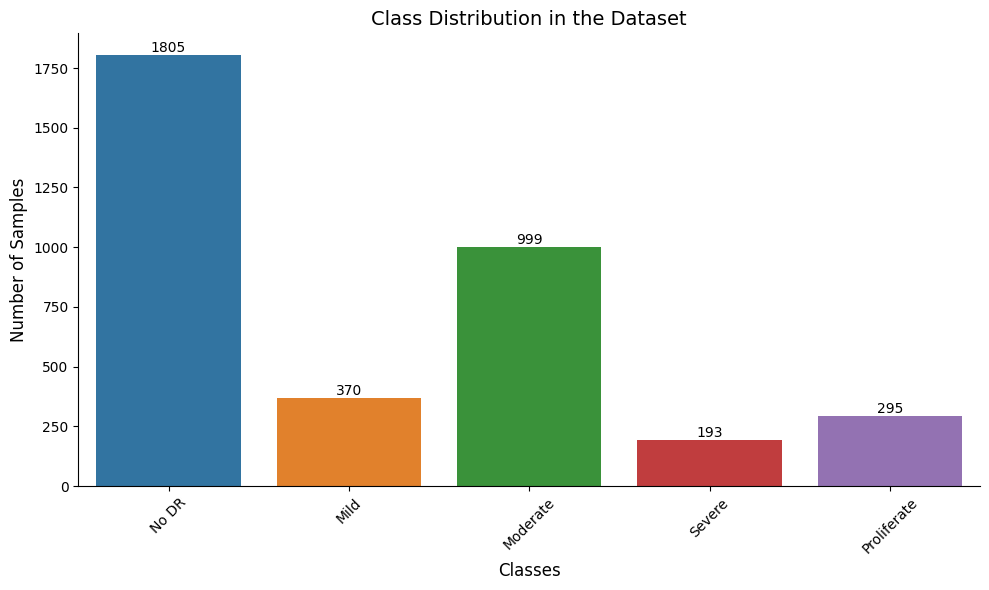

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute class_counts first
class_counts = train['label'].value_counts()



# Define the desired order for x-axis labels
desired_order = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferate']

# Create a bar chart with improved aesthetics and custom order
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=class_counts.index, y=class_counts.values,  order=desired_order)

# Add labels and title
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.title('Class Distribution in the Dataset', fontsize=14)

# Customize x-axis labels for readability
ax.set_xticklabels(desired_order, rotation=45, fontsize=10)

# Annotate each bar with the count
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

# Remove top and right spines
sns.despine()

# Show the plot
plt.tight_layout()
plt.show()

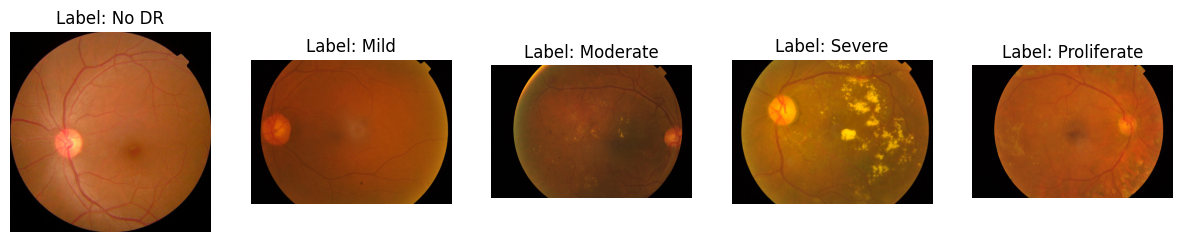

In [9]:
# Create a figure with subplots for each label
num_labels = 5
fig, axes = plt.subplots(1, num_labels, figsize=(15, 5))

# Define a mapping from numeric labels to text labels
label_mapping = {
    0: 'No DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferate'
}

# Iterate through the labels and select one image for each label
for label in range(num_labels):
    # Get the first row for the current label
    row_for_label = train[train['diagnosis'] == label].iloc[0]

    # Get the filename (id_code)
    filename = row_for_label['id_code']

    # Construct the full path to the image file
    image_file = os.path.join("/kaggle/input/aptos2019-blindness-detection/train_images", filename)

    # Load and display the image
    image_data = cv2.imread(image_file)

    if image_data is not None:
        axes[label].imshow(cv2.cvtColor(image_data, cv2.COLOR_BGR2RGB))
        axes[label].set_title(f'Label: {label_mapping[label]}')
        axes[label].axis('off')
    else:
        axes[label].set_title(f'Label: {label_mapping[label]} (No Image)')
        axes[label].axis('off')

plt.show()

In [10]:
# Specify the name of your output folder
output_folder_name = 'processed_images'

# Get the current working directory
current_directory = os.getcwd()

# Create the path to the output folder
output_folder_path = os.path.join(current_directory, output_folder_name)

# Create the output folder if it doesn't exist
if not os.path.exists(output_folder_path):
    os.makedirs(output_folder_path)
    print(f"Output folder '{output_folder_name}' created.")
else:
    print(f"Output folder '{output_folder_name}' already exists.")

Output folder 'processed_images' created.


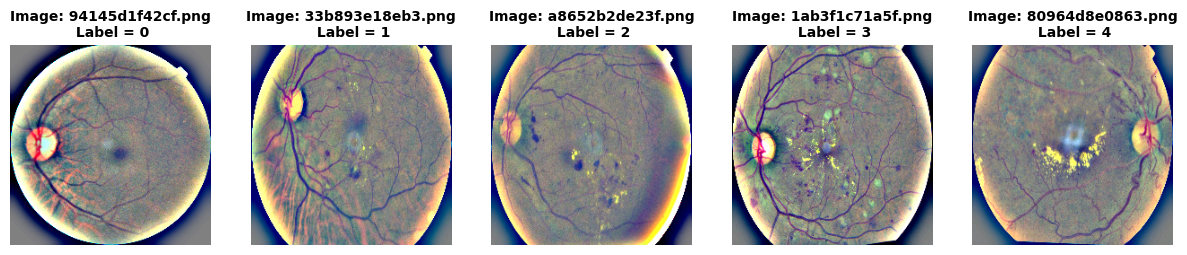

In [11]:

import cv2
import matplotlib.pyplot as plt
import numpy as np

# Define image paths and parameters
TRAIN_IMG_PATH = "/kaggle/input/aptos2019-blindness-detection/train_images"
IMG_WIDTH = 224
IMG_HEIGHT = 224
SIGMA_X = 10
TOL = 7

# Function to crop image based on grayscale threshold
def crop_image_from_gray(img, tol=TOL):
  """
  Applies masks to the original image and returns the a preprocessed image with 3 channels.

  Args:
      img: A NumPy array that will be cropped
      tol: The tolerance used for masking

  Returns:
      A NumPy array containing the cropped image
  """
  # If grayscale image
  if img.ndim == 2:
    mask = img > tol
    return img[np.ix_(mask.any(1), mask.any(0))]
  # If RGB image
  elif img.ndim == 3:
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray_img > tol

    # Check if any pixels remain after masking
    check_shape = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))].shape[0]
    if check_shape == 0:
      # Return original image if no pixels remain
      return img
    else:
      # Extract and stack remaining channels
      img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
      img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
      img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]
      img = np.stack([img1, img2, img3], axis=-1)
    return img

# Function to preprocess image
def preprocess_image(image, sigmaX=SIGMA_X):
  """
  Applies preprocessing steps to the image.

  Args:
      image: A NumPy array representing the image
      sigmaX: Value used for adding Gaussian blur

  Returns:
      A NumPy array containing the preprocessed image
  """
  # Convert to RGB
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

  # Crop based on grayscale threshold
  image = crop_image_from_gray(image)

  # Resize image
  image = cv2.resize(image, (IMG_WIDTH, IMG_HEIGHT))

  # Add Gaussian noise for robustness
  image = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0, 0), sigmaX), -4, 128)

  return image

# Display preprocessed images
fig, ax = plt.subplots(1, 5, figsize=(15, 6))

# Sample and process images for each label
for i in range(5):
  sample = train[train['diagnosis'] == i].sample(1)
  image_name = sample['id_code'].item()
  image = cv2.imread(f"{TRAIN_IMG_PATH}/{image_name}")
  preprocessed_image = preprocess_image(image)

  ax[i].set_title(f"Image: {image_name}\n Label = {sample['diagnosis'].item()}", weight="bold", fontsize=10)
  ax[i].axis("off")
  ax[i].imshow(preprocessed_image)

plt.show()

In [12]:
# Create directory for preprocessed images
PREPROCESSED_IMG_PATH='/kaggle/working/processed_images'
#if not os.path.exists(PREPROCESSED_IMG_PATH):
  #os.makedirs(PREPROCESSED_IMG_PATH)

# Preprocess and save images
for filename in os.listdir(TRAIN_IMG_PATH):
  image = cv2.imread(os.path.join(TRAIN_IMG_PATH, filename))
  preprocessed_image = preprocess_image(image)

  # Save preprocessed image
  cv2.imwrite(os.path.join(PREPROCESSED_IMG_PATH, filename), preprocessed_image)

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import  EfficientNetB7,EfficientNetB0
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import cohen_kappa_score, matthews_corrcoef

In [16]:
TRAIN_IMG_PATH = "/kaggle/working/preprocessed_images"


IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
SEED = 42

In [21]:
train['diagnosis'] = train['diagnosis'].astype(str)

In [22]:
from sklearn.model_selection import train_test_split
X = train['id_code']
y = train['diagnosis']
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

train_df = pd.DataFrame({'id_code': X_train, 'diagnosis': y_train}).reset_index(drop=True)
valid_df = pd.DataFrame({'id_code': X_valid, 'diagnosis': y_valid}).reset_index(drop=True)

In [23]:
# Create data generators for image data
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1 / 255.0,
                                                               rotation_range=10,
                                                               zoom_range=0.30,
                                                               shear_range=0.30,
                                                               fill_mode="nearest")

valid_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1 / 255.0)

In [24]:
images_directory = "/kaggle/working/processed_images"
batch_size = 16
train_generator = train_datagen.flow_from_dataframe(dataframe=train_df,
                                                    directory=images_directory,
                                                    x_col='id_code',
                                                    y_col='diagnosis',
                                                    target_size=(224, 224),
                                                    color_mode='rgb',
                                                    class_mode='categorical',
                                                    batch_size=batch_size)

valid_generator = valid_datagen.flow_from_dataframe(dataframe=valid_df,
                                                    directory=images_directory,
                                                    x_col='id_code',
                                                    y_col='diagnosis',
                                                    target_size=(224, 224),
                                                    color_mode='rgb',
                                                    class_mode='categorical',
                                                    batch_size=batch_size)

Found 2929 validated image filenames belonging to 5 classes.
Found 733 validated image filenames belonging to 5 classes.


In [ ]:
efficientnet_b0_model = create_model(EfficientNetB0(include_top=False, weights="imagenet"), 5)
efficientnet_b7_model = create_model(EfficientNetB7(include_top=False, weights="imagenet"), 5)

In [38]:

from tensorflow.keras.applications import EfficientNetB0, EfficientNetB7
from tensorflow.keras.layers import Input, Concatenate, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd

# Set the directory where your processed images are stored
images_directory = "/kaggle/working/processed_images"

# Set batch size
batch_size = 16

# Define data generators
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(dataframe=train_df,
                                                    directory=images_directory,
                                                    x_col='id_code',
                                                    y_col='diagnosis',
                                                    target_size=(224, 224),
                                                    color_mode='rgb',
                                                    class_mode='categorical',
                                                    batch_size=batch_size)

valid_generator = valid_datagen.flow_from_dataframe(dataframe=valid_df,
                                                    directory=images_directory,
                                                    x_col='id_code',
                                                    y_col='diagnosis',
                                                    target_size=(224, 224),
                                                    color_mode='rgb',
                                                    class_mode='categorical',
                                                    batch_size=batch_size)

# Create EfficientNet B0 model
efficientnet_b0_model = EfficientNetB0(include_top=False, weights="imagenet")

# Create EfficientNet B7 model
efficientnet_b7_model = EfficientNetB7(include_top=False, weights="imagenet")

# Define input layer
input_layer = Input(shape=(224, 224, 3))

# Get outputs from both models
output_b0 = efficientnet_b0_model(input_layer)
output_b7 = efficientnet_b7_model(input_layer)

# Concatenate the outputs
concatenated_output = Concatenate()([output_b0, output_b7])

# Global average pooling
pooled_output = GlobalAveragePooling2D()(concatenated_output)

# Dense layer for multi-class classification
num_classes = 5  # Replace 5 with the actual number of classes in your dataset
output_layer = Dense(num_classes, activation='softmax')(pooled_output)

# Create the ensemble model
ensemble_model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
ensemble_model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
ensemble_model.summary()

# Define number of epochs
epochs = 50

# Train the ensemble model
history_ensemble = ensemble_model.fit(train_generator,
                                      epochs=epochs,
                                      validation_data=valid_generator)

# Convert the training history to a DataFrame
ensemble_history_df = pd.DataFrame(history_ensemble.history)


Found 2929 validated image filenames belonging to 5 classes.
Found 733 validated image filenames belonging to 5 classes.
Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_15 (InputLayer)       [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 efficientnetb0 (Functional  (None, None, None, 1280)     4049571   ['input_15[0][0]']            
 )                                                                                                
                                                                                                  
 efficientnetb7 (Functional  (None, None, None, 2560)     6409768   ['input_15[0][0]']            
 )                                                        7           

2024-02-06 07:20:18.346156: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_5/efficientnetb7/block1b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


184/184 [==============================] - 367s 1s/step - loss: 0.7645 - accuracy: 0.7183 - val_loss: 2.3117 - val_accuracy: 0.4789
Epoch 2/50
184/184 [==============================] - 182s 992ms/step - loss: 0.5409 - accuracy: 0.8003 - val_loss: 1.3936 - val_accuracy: 0.4311
Epoch 3/50
184/184 [==============================] - 181s 983ms/step - loss: 0.4582 - accuracy: 0.8242 - val_loss: 16.2762 - val_accuracy: 0.4734
Epoch 4/50
184/184 [==============================] - 181s 982ms/step - loss: 0.4079 - accuracy: 0.8426 - val_loss: 3.6304 - val_accuracy: 0.4475
Epoch 5/50
184/184 [==============================] - 181s 982ms/step - loss: 0.3451 - accuracy: 0.8747 - val_loss: 1.8420 - val_accuracy: 0.4789
Epoch 6/50
184/184 [==============================] - 181s 982ms/step - loss: 0.2923 - accuracy: 0.8921 - val_loss: 11.4546 - val_accuracy: 0.4789
Epoch 7/50
184/184 [==============================] - 181s 982ms/step - loss: 0.2266 - accuracy: 0.9167 - val_loss: 2.3680 - val_accurac

In [46]:
data = {
    'accuracy': [0.9483],
    'model': ['EfficientNet B0']
}

# Create the DataFrame
B0df = pd.DataFrame(data)

# Print the DataFrame
print(B0df)

   accuracy            model
0    0.9483  EfficientNet B0


In [47]:
data = {
    'accuracy': [ 0.9264],
    'model': ['EfficientNet B7']
}

# Create the DataFrame
B7df = pd.DataFrame(data)

# Print the DataFrame
print(B7df)

   accuracy            model
0    0.9264  EfficientNet B7


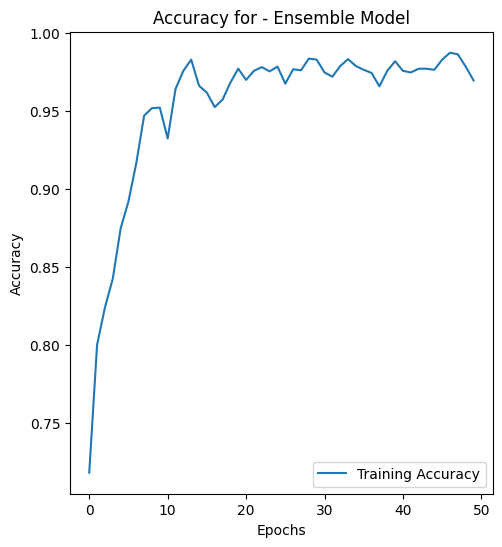

In [41]:
ensemble_history_df
# Plot accuracy vs validation accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(ensemble_history_df['accuracy'], label='Training Accuracy')

plt.title('Accuracy for - {}'.format("Ensemble Model"))
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

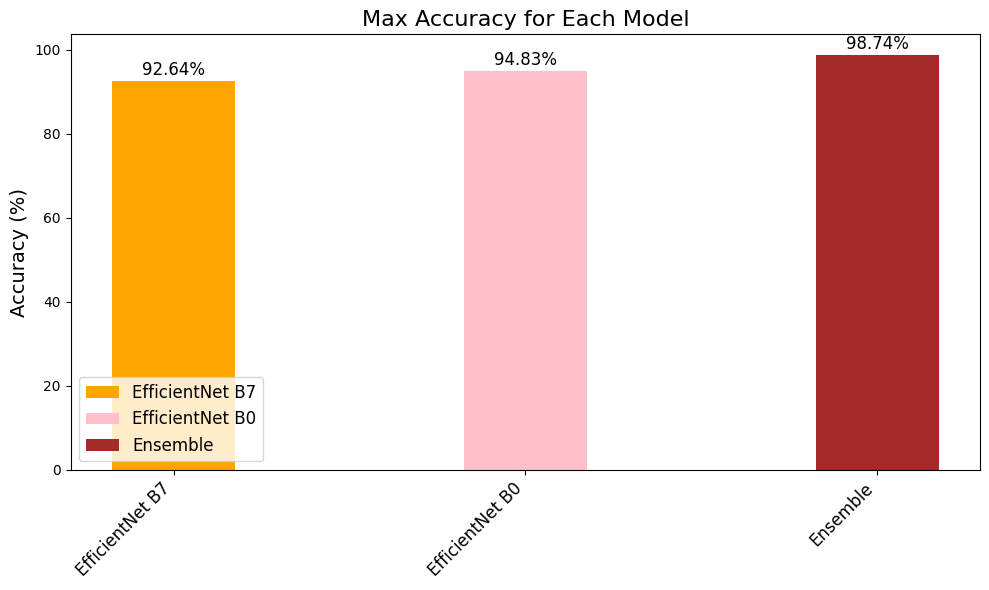

In [49]:
import matplotlib.pyplot as plt
import numpy as np

dataframes = [B7df, B0df, ensemble_history_df]

# Extracting accuracy values from each dataframe
accuracy_values = [df['accuracy'].max() * 100 for df in dataframes]

# Model names for x-axis
model_names = ['EfficientNet B7', 'EfficientNet B0', 'Ensemble']

# Plotting the vertical bar graphs
fig, ax = plt.subplots(figsize=(10, 6))  # Adjust the figure size

bar_width = 0.35
index = np.arange(len(model_names))

# Specify different colors for the bars
colors = ['orange', 'pink', 'brown']

# Plotting the bars
for i in range(len(model_names)):
    ax.bar(index[i], accuracy_values[i], bar_width, label=model_names[i], color=colors[i])

ax.set_title('Max Accuracy for Each Model', fontsize=16)
ax.set_ylabel('Accuracy (%)', fontsize=14)
ax.set_xticks(index)
ax.set_xticklabels(model_names, fontsize=12, rotation=45, ha='right')
ax.legend(fontsize=12,loc='lower left')

# Annotate values on top of the bars
for i, v in enumerate(accuracy_values):
    ax.text(i, v + 0.5, f'{v:.2f}%', ha='center', va='bottom', color='black', fontsize=12)

plt.tight_layout()
plt.show()

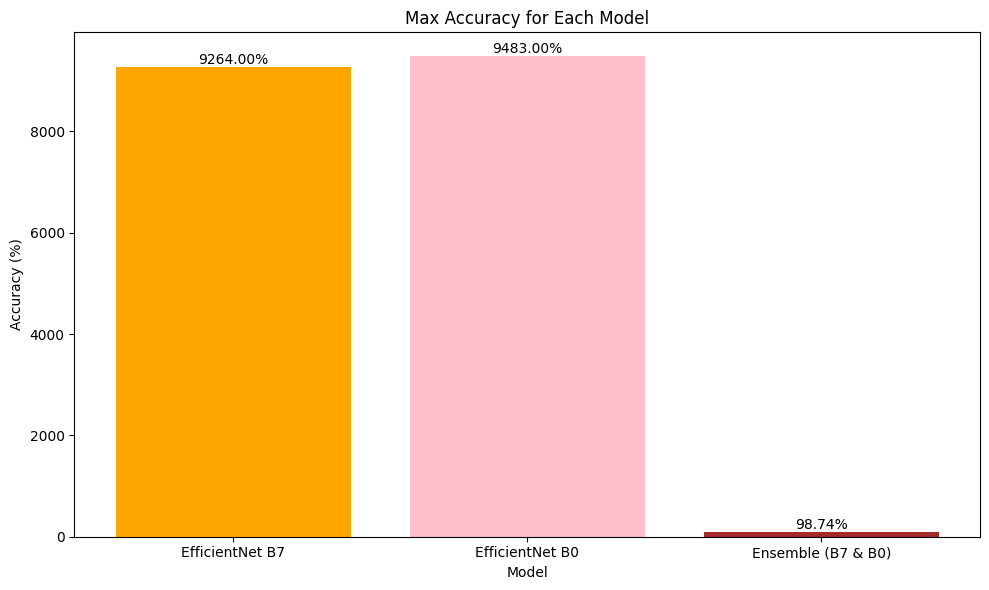

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have the following dataframes
dataframes = [B7df, B0df, ensemble_history_df]

# Extracting accuracy values from each dataframe
accuracy_values = [df['accuracy'].max() * 100 for df in dataframes]

# Model names for x-axis
model_names = ['EfficientNet B7', 'EfficientNet B0', 'Ensemble (B7 & B0)']

# Plotting the vertical bar graphs
plt.figure(figsize=(10, 6))  # Adjust the figure size

# Specify different colors
colors = ['orange', 'pink', 'brown']

# Plotting the bar graph
plt.bar(model_names, accuracy_values, color=colors)

# Adding labels and title
plt.title('Max Accuracy for Each Model')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')

# Annotate values on top of the bars
for i, v in enumerate(accuracy_values):
    plt.text(i, v + 0.5, f'{v:.2f}%', ha='center', va='bottom', color='black')

plt.tight_layout()
plt.show()
